In [163]:
from skimage.io import imread
import numpy as np
from scipy.fftpack import dct, idct
from scipy.signal import convolve2d
from matplotlib import pyplot as plt
import time
import lib

In [164]:
rootfolder = '.'

In [165]:
np.random.seed(12345)

Definition of dct2 and idct2 (they are not builtin functions)

In [166]:
def dct2(s):
    return dct(dct(s.T, norm='ortho').T, norm='ortho')

def idct2(x):
    return idct(idct(x.T, norm='ortho').T, norm='ortho')

Useful function for plot the 2D DCT dictionary

In [167]:
def get_dictionary_img(D):
    M = D.shape[0]
    p = int(round(np.sqrt(M)))
    bound = 2
    img = np.ones((p*p+bound*(p-1), p*p+bound*(p-1)))
    for i in range(M):
        m = np.mod(i, p)
        n = int((i-m)/p)
        m = m * p + bound * m
        n = n * p + bound * n
        atom = D[:, i].reshape((p, p))
        if atom.min() < atom.max():
            atom = (atom - atom.min()) / (atom.max() - atom.min())
        img[m: m + p, n: n + p] = atom

    return img

Load the image and rescale it in $[0,1]$

In [168]:
img = imread(f'{rootfolder}/data/cameraman.png') / 255
imsz = img.shape

# patch size
p = 8

# number of elements in the patch
M = p ** 2

Corrupt the image with white gaussian noise

In [169]:
sigma_noise = 20/255
noisy_img = img + np.random.normal(size=imsz) * sigma_noise

Compute the psnr of the noisy input

In [170]:
psnr_noisy = lib.get_psnr(img, noisy_img)

Text(0.5, 1.0, 'Noisy image, PSNR = 22.10')

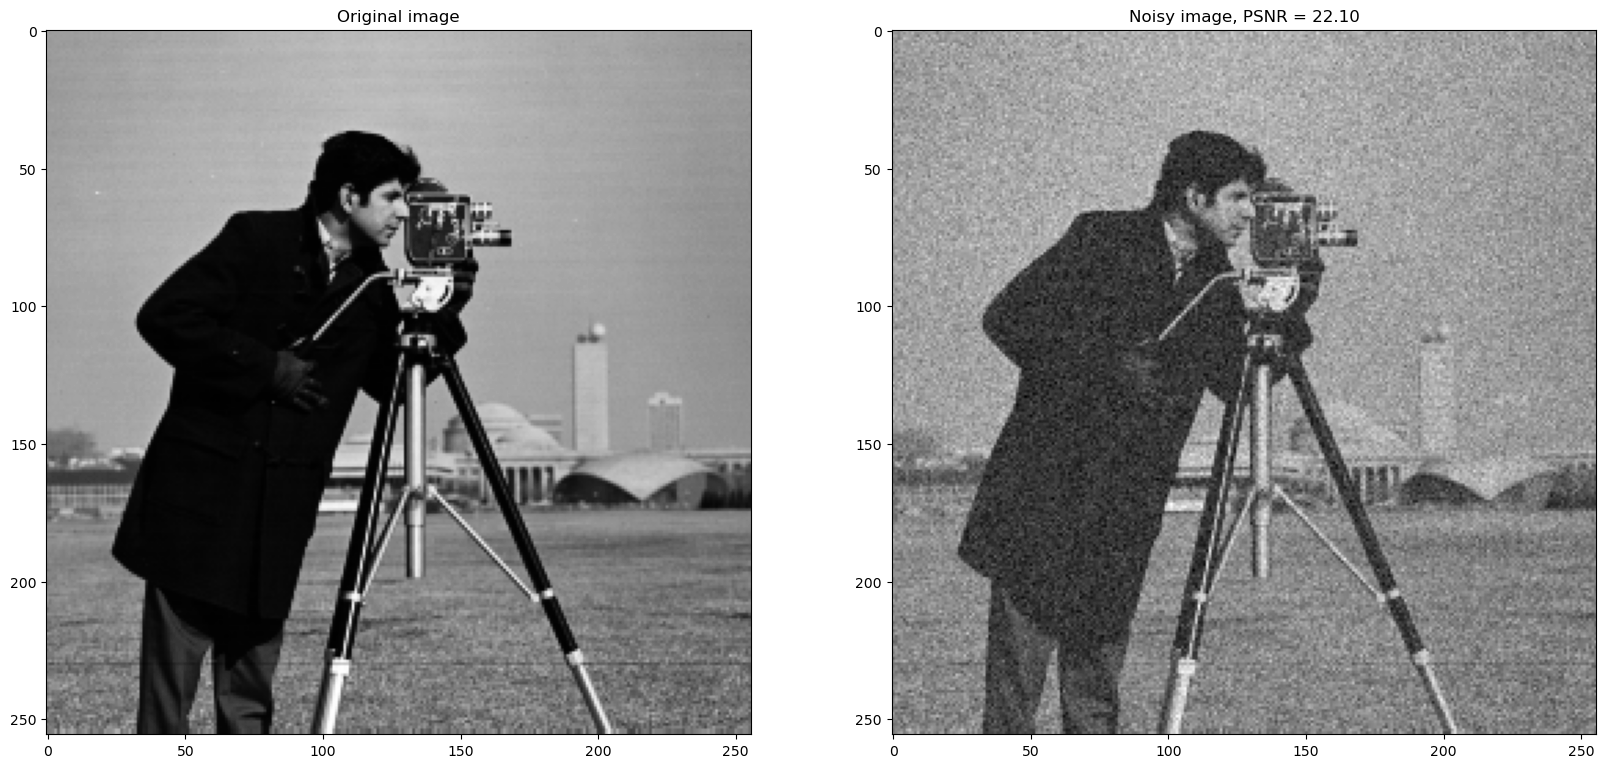

In [171]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original image')

ax[1].imshow(noisy_img, cmap='gray')
ax[1].set_title(f'Noisy image, PSNR = {psnr_noisy:.2f}')


DCT denoising
-------------
Generate the DCT basis

In [172]:
D = np.zeros((M, M))
cnt = 0
for i in range(p):
    for j in range(p):
        A = np.zeros((p, p))
        A[i, j] = 1
        D[:, cnt] = idct2(A).flatten()
        cnt = cnt + 1

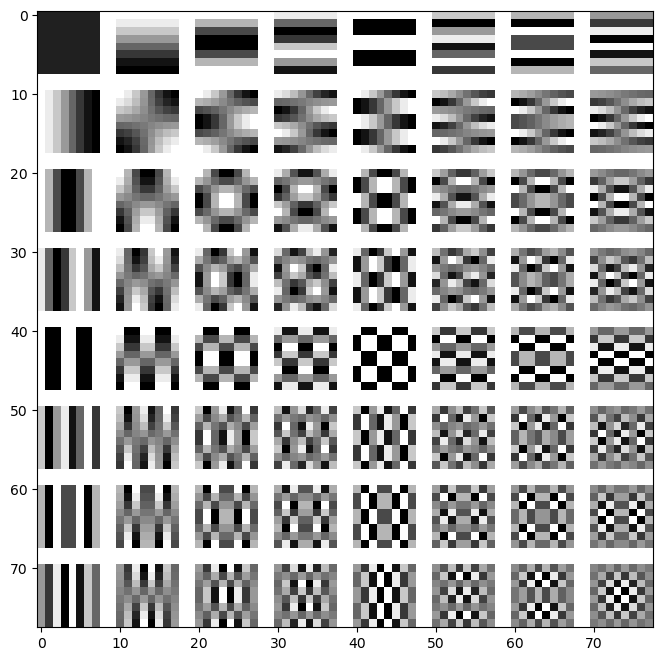

In [173]:
D_img = get_dictionary_img(D)
plt.figure(figsize=(8, 8))
plt.imshow(D_img, cmap='gray')

Denoising: set parameters and initialize the variables

In [174]:
# initialize the estimated image
img_hat = np.zeros_like(img)

# initialize the weight matrix
weights = np.zeros_like(img)

# set the threshold for the Hard Thresholding
tau = 3 * sigma_noise # Donoho says: sigma * sqrt(2*log(p^2))

# define the step
STEP = 1

Perform the denoising pathwise

In [175]:
for i in range(0, imsz[0] - p + 1, STEP):
    for j in range(0, imsz[1] - p + 1, STEP):
        # extrach the patch with the top left corner at pixel (ii, jj)
        s = noisy_img[i:i + p, j:j + p]

        # compute the representation w.r.t. the 2D DCT dictionary
        x = dct2(s)

        # perform the hard thresholding (do not perform HT on the DC!)
        x_HT = lib.hard_thresholding(x, tau)
        
        # restore the DC component
        x_HT[0, 0] = x[0, 0]

        # perform the reconstruction
        s_hat = idct2(x_HT)

        # compute the weight for the reconstructed patch
        w = 1 / max(1, np.count_nonzero(x_HT))

        # put the compressed patch into the compressed image using the computed weight
        # update img_hat
        img_hat[i:i + p, j:j + p] += s_hat * w

        # store the weight of the current patch in the weight matrix
        # update weights
        weights[i:i + p, j:j + p] += w

Normalize the estimated image with the computed weights

In [176]:
img_hat = img_hat / weights

Compute the psnr of the estimated image

Text(0.5, 1.0, 'Estimated Image,\nPSNR = 29.10')

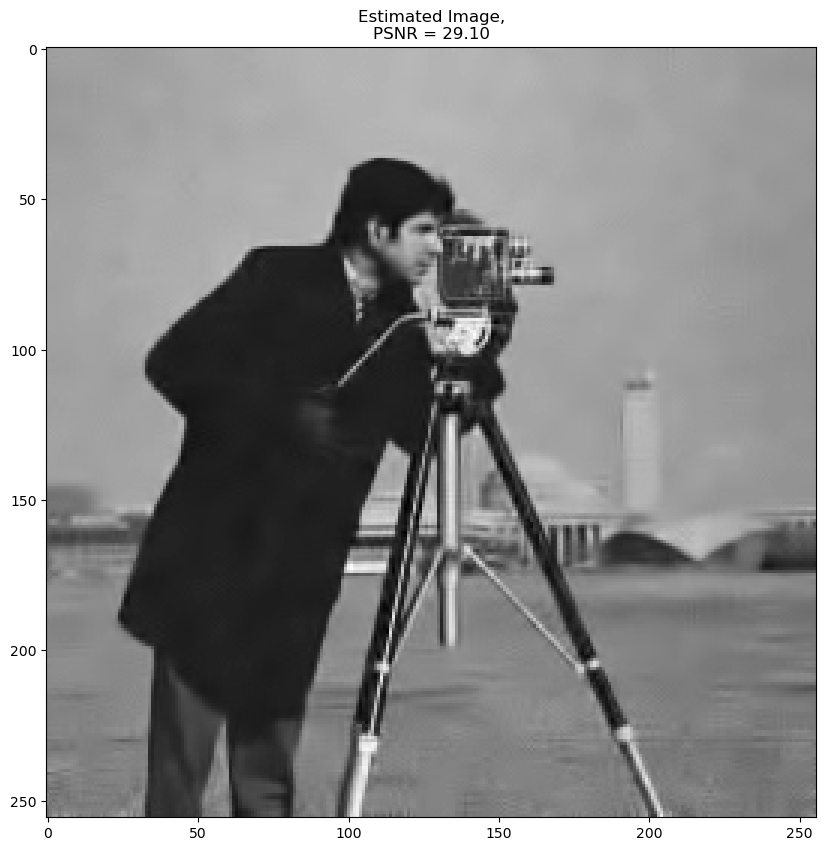

In [177]:
psnr_dct_denoising = lib.get_psnr(img, img_hat)
plt.figure(figsize=(10,10))
plt.imshow(img_hat, cmap='gray')
plt.title(f'Estimated Image,\nPSNR = {psnr_dct_denoising:.2f}')

Wiener Filtering
----------------
Initialize the estimated image via Wiener Filtering

In [178]:
img_hat_wiener = np.zeros_like(img)
weights = np.zeros_like(img)

Perform the denoising patchwise

In [179]:
for i in range(0, imsz[0] - p + 1, STEP):
    for j in range(0, imsz[1] - p + 1, STEP):
        # extrach the patch from the noisy image with the top left corner at pixel (ii, jj)
        s = noisy_img[i:i + p, j:j + p]

        # compute the representation w.r.t. the 2D DCT dictionary
        x = dct2(s)

        # extrach the patch from the image estimated by HT with the top left corner at pixel (ii, jj)
        s_hat_HT = img_hat[i:i + p, j:j + p]

        u_ij = dct2(s_hat_HT)

        # perform the wiener filtering (do not filter the DC!)
        x_wie = x * (u_ij ** 2 / (sigma_noise ** 2 + u_ij ** 2))

        # perform the reconstruction
        s_hat_wie = idct2(x_wie)

        # use uniform weights to aggregate the multiple estimates
        # otherwise we have not theoretical guarantees
        w = 1

        # put the compressed patch into the compressed image using the computed weight
        # update img_hat_wiener
        img_hat_wiener[i:i + p, j:j + p] += s_hat_wie

        # store the weight of the current patch in the weight matrix
        # update weights
        weights[i:i + p, j:j + p] += w

# Normalize the estimated image with the computed weights
img_hat_wiener = img_hat_wiener / weights

Compute the psnr of the two estimates

Text(0.5, 1.0, 'Wiener Estimate, PSNR = 29.38')

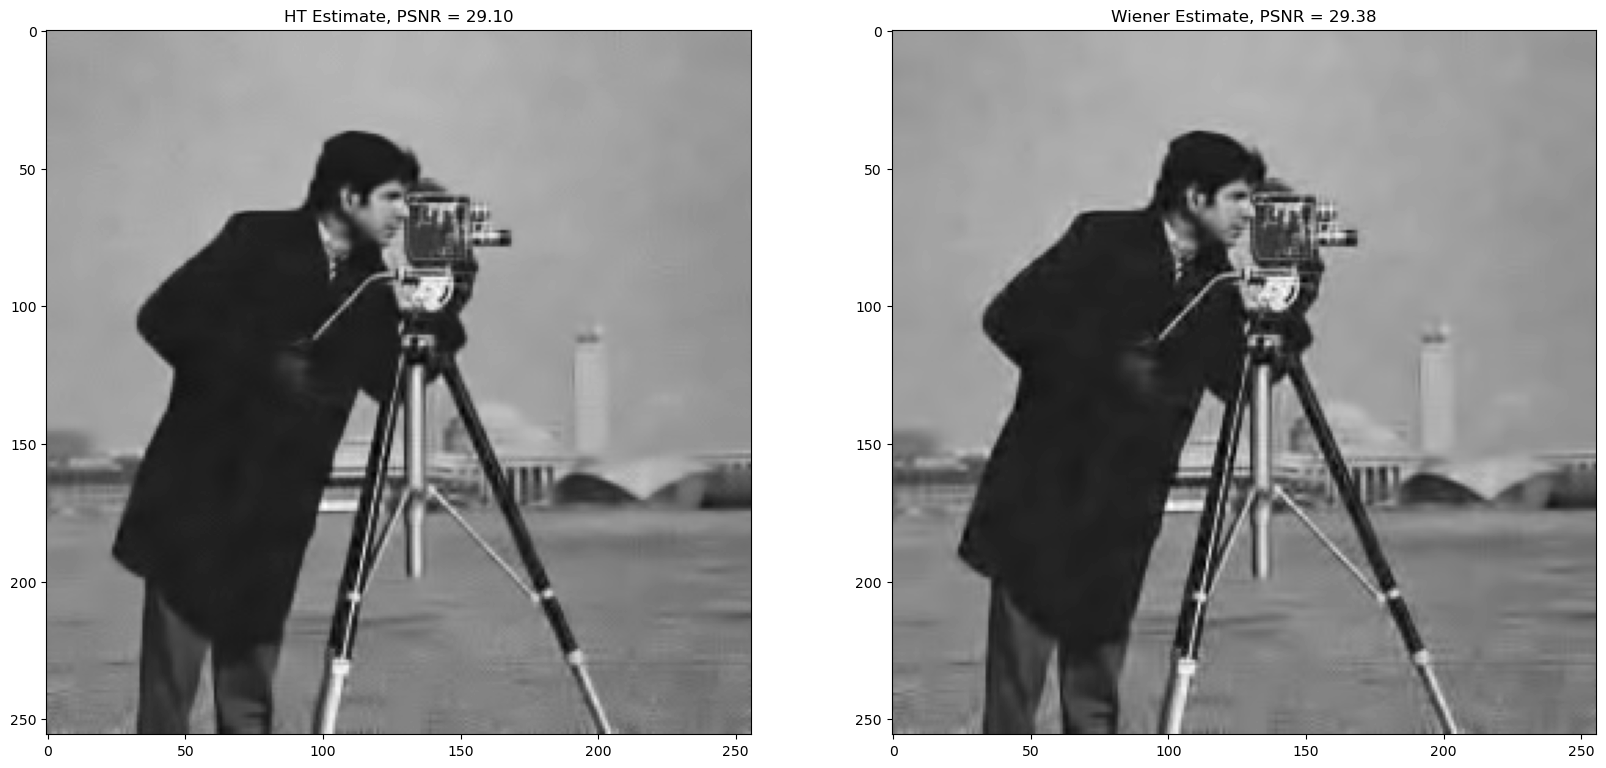

In [180]:
psnr_wiener = lib.get_psnr(img, img_hat_wiener)

fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(img_hat, cmap='gray')
ax[0].set_title(f'HT Estimate, PSNR = {psnr:.2f}')

ax[1].imshow(img_hat_wiener, cmap='gray')
ax[1].set_title(f'Wiener Estimate, PSNR = {psnr_wiener:.2f}')


Noise estimation
----------------
Compute the horizontal derivative of the image

In [181]:
differences = img - img_hat_wiener

Compute sigma as the empirical std

In [182]:
sigma_hat_emp = np.std(differences.flatten()) / np.sqrt(2)

Use MAD to estimate the noise level sigma

**Normalize the MAD**: Since the MAD corresponds to the 75th percentile of the normal distribution, we divide by 0.6745 (the 75th percentile value for the standard normal distribution) to obtain an estimate for the standard deviation.

In [183]:
mad = np.median(np.abs(differences.flatten() - np.median(differences.flatten())))

# get the std from the MAD

sigma_hat = mad / 0.6745

In [184]:
print(f'sigma: {sigma_noise:.3f}, sigma_hat (empirical std): {sigma_hat_emp:.3f}, sigma_hat (MAD): {sigma_hat:.3f}')

sigma: 0.078, sigma_hat (empirical std): 0.024, sigma_hat (MAD): 0.019
